In [48]:
import os 
import glob 
import math

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [49]:
# windows
os.chdir("C:\\Users\\HP\\Desktop\\Research")

### Calculating the Eucleadean Distance between 1st leader and follower  
### Add selected leader variables. 
### Add lat. variables. 

In [42]:
from codes.simulation_code.eucli_dist import mtm_varible_addition

In [43]:
# Define the path to the directory containing the CSV files
# windows
#path = 'data\\milano\\neighbor_pairs\\'  
path = 'data\\milano\\for_mtm\\'  


# Use glob to get all the CSV files in the directory
all_files = glob.glob(path + "leader_follower_pair_*.csv") #multiple neighbor
 
# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

In [44]:
len(dfs)

315

In [6]:
# cut the unreliable corner values 
for i in range(len(dfs)):
    dfs[i] = dfs[i][(dfs[i]['x_rot'] > 50) & (dfs[i]['x_rot'] < 850)]
    
# reduce the frequency 
# for i in range(len(dfs)): 
#     dfs[i] = dfs[i].iloc[::5, :]
    

In [7]:
# change for the reverse. x values 
# only run one time otherwise re run the whole thing 
for i in range(len(dfs)): 
    
    dfs[i]['x_rot'] = 950 - dfs[i]['x_rot']
    dfs[i]['x_rot_1'] = 950 - dfs[i]['x_rot_1']
    dfs[i]['x_rot_2'] = 950 - dfs[i]['x_rot_2']
    dfs[i]['x_rot_3'] = 950 - dfs[i]['x_rot_3']
    dfs[i]['x_rot_4'] = 950 - dfs[i]['x_rot_4']   
    dfs[i]['x_rot_5'] = 950 - dfs[i]['x_rot_5']
    dfs[i]['x_rot_6'] = 950 - dfs[i]['x_rot_6']



C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1930458566.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs[i]['x_rot'] = 950 - dfs[i]['x_rot']
C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1930458566.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs[i]['x_rot_1'] = 950 - dfs[i]['x_rot_1']
C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1930458566.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [8]:
dfs[56]

,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,...,Angle [rad]_6,vehicle_id_6,flw_type_6,entry_6,exit_6,length_6,width_6,x_rot_6,y_rot_6,lanes_6
71,234361,512225.61,5026313.51,95.3866,0.0042,-0.0611,47.347393,2.6836,251.0,Car,...,2.6802,245.0,Car,Gate 202,Gate 201,5.0,2.0,107.506694,95.503075,6.0
72,234362,512224.82,5026313.90,95.3907,0.0642,-0.0562,47.380760,2.6837,251.0,Car,...,2.6803,245.0,Car,Gate 202,Gate 201,5.0,2.0,108.186463,95.499375,6.0
73,234363,512224.03,5026314.29,95.4015,0.1154,-0.0501,47.414127,2.6838,251.0,Car,...,2.6804,245.0,Car,Gate 202,Gate 201,5.0,2.0,108.857283,95.500136,6.0
74,234364,512223.24,5026314.68,95.4179,0.1580,-0.0450,47.447493,2.6838,251.0,Car,...,2.6805,245.0,Car,Gate 202,Gate 201,5.0,2.0,109.528103,95.500898,6.0
75,234365,512222.44,5026315.07,95.4395,0.2013,-0.0396,47.480860,2.6839,251.0,Car,...,2.6805,245.0,Car,Gate 202,Gate 201,5.0,2.0,110.207872,95.497198,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,235226,511512.61,5026664.50,105.8332,0.8233,-0.2180,76.209617,2.6836,251.0,Car,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
937,235227,511511.74,5026664.93,105.9288,0.7690,-0.2218,76.242984,2.6839,251.0,Car,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
938,235228,511510.86,5026665.36,106.0155,0.6742,-0.2211,76.276350,2.6841,251.0,Car,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,235229,511509.99,5026665.79,106.0928,0.6121,-0.2203,76.309717,2.6844,251.0,Car,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# calculate the euc. gap 
dfs_new = []

for df in dfs: 

    df_sample = df.copy()

    calc = mtm_varible_addition(df_sample)

    # # select. leader. and give positions 
    # updated_df =  calc.leader_variables_select()

    # cal. euc. gap. 
    updated_df =  calc.calcualte_gap()

    #long. acc. calculation. 
    updated_df = calc.lon_speed_calc()

    #lat. speed. calculation. 
    updated_df = calc.lat_speed_calc()

    #lat. acc. calculation. 
    updated_df = calc.lat_acc_calc()

    #long. acc. calculation. 
    updated_df = calc.lon_acc_calc()

    # boundary variables. addition 
    updated_df = calc.boundary_variables()

    # lat. gap. calc. 
    #updated_df = calc.lateral_gap()

    # append to the new list. 
    dfs_new.append(updated_df)


In [10]:
# change the lat- acc side. 
for i in range(len(dfs_new)): 
    
    dfs_new[i] = dfs_new[i].iloc[:-2]

In [45]:
# df = dfs_new[55].reset_index()
df = dfs_new[55]

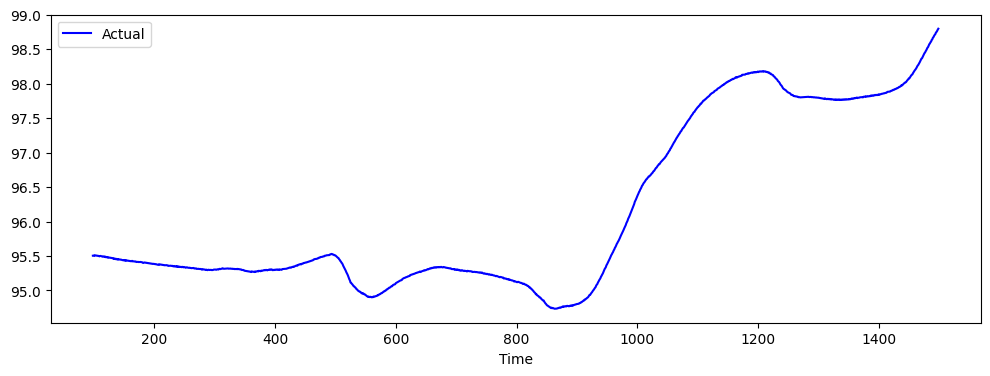

In [46]:
plt.figure(figsize=(12, 4))

plt.plot(df['y_rot'],   color='b',  label = 'Actual')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

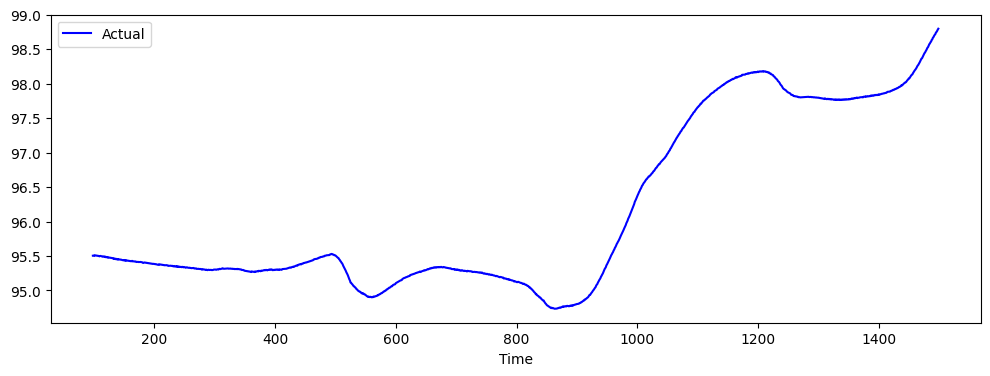

In [12]:
plt.figure(figsize=(12, 4))

plt.plot(df['y_rot'],   color='b',  label = 'Actual')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_lat'],   color='y',  label = 'without smoothing')
plt.plot(df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

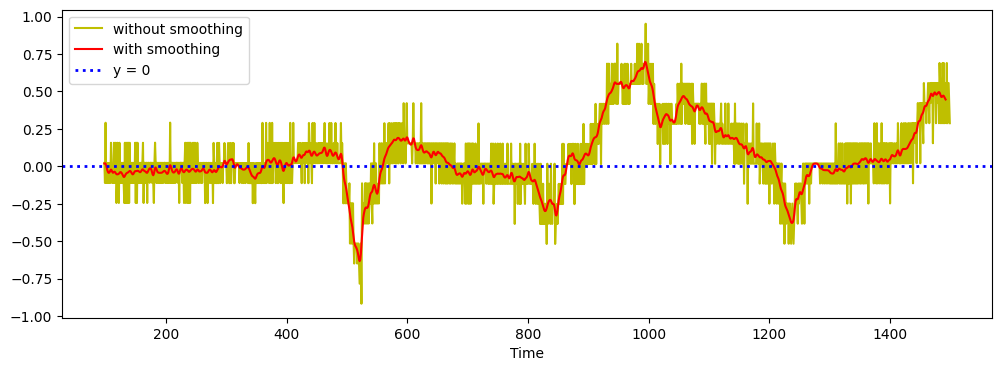

In [23]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_lat'],   color='y',  label = 'without smoothing')
plt.plot(df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

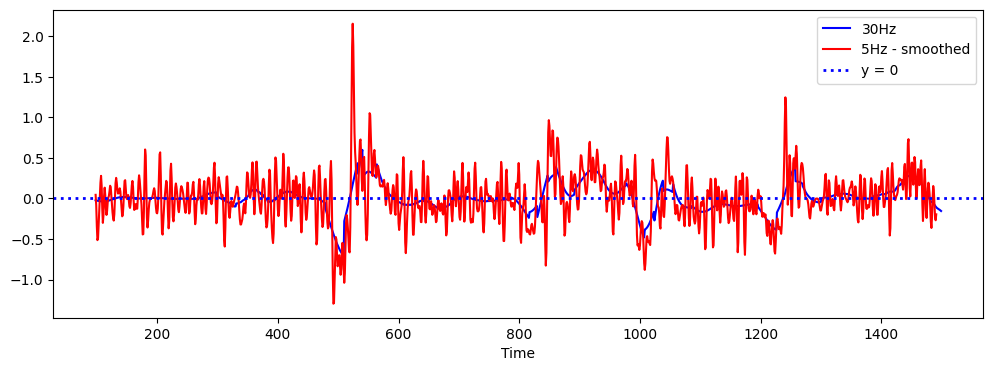

In [30]:
plt.figure(figsize=(12, 4))

plt.plot(df['Lat. Acc. [ms-2]'],   color='b',  label = '30Hz')
#plt.plot(df['Lat. Acc. [ms-2]_new'],   color='y',  label = '5Hz - calculated')
plt.plot(df['Lat. Acc. [ms-2]_new_f'],   color='r',  label = '5Hz - smoothed')
#plt.plot(-df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
#plt.plot(df['Lat. Acc. [ms-2]_new_new'],   color='red',  label = 'smooth')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

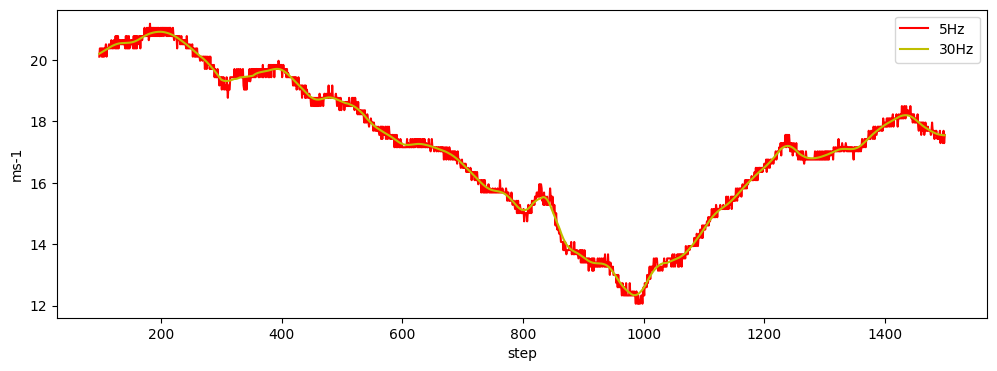

In [31]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_new'],   color='r',  label = '5Hz')
plt.plot(df['Speed [km/h]']*0.2777778 ,   color='y',  label = '30Hz')

#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('step')
plt.ylabel('ms-1')
plt.legend()

#plt.savefig('figures//5Hzvs30Hz_veh55.jpg', dpi = 300)
plt.show()

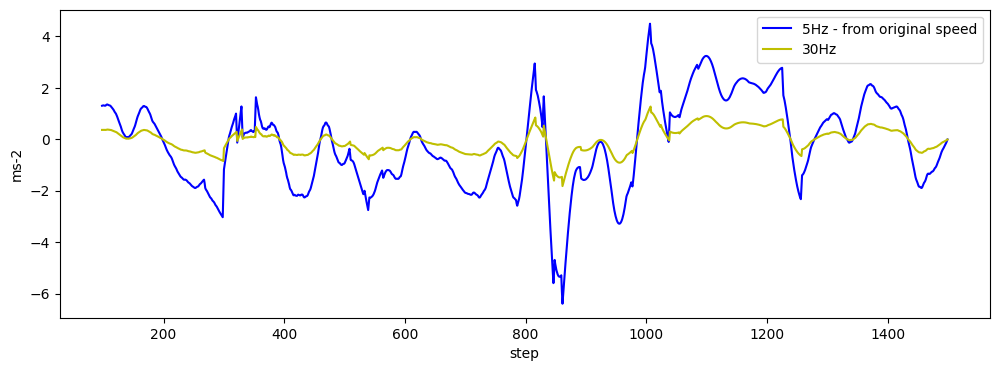

In [26]:
plt.figure(figsize=(12, 4))

plt.plot(df['Tan. Acc. [ms-2]_o'],   color='b',  label = '5Hz - from original speed')
#plt.plot(df['Tan. Acc. [ms-2]_new'],   color='r',  label = '5Hz')
plt.plot(df['Tan. Acc. [ms-2]'] ,   color='y',  label = '30Hz')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('step')
plt.ylabel('ms-2')
plt.legend()

#plt.savefig('figures//5Hzvs30Hz_veh55.jpg', dpi = 300)
plt.show()

notes: 
1. smoothed speed will be used for the lateral speed
2. lateral. acc will be calculated from the smoothed speed.

3. long speed will be the one from the 30 Hz. as the new one is too noisy.
4. lat speed will the one orignally commes.

we need to discuss about this further with ANKIT. 

In [32]:
def relative_feature_adding(dataframe): 
    
    """Adding the relative speed and gap values for multiple neighbors"""


    for idx, row in dataframe.iterrows():

        # This is based on the correct x direction. 
        # 1,2,3 are followers and 4,5,6 are leaders.
        dataframe.at[idx, 'Rel_x[m]_1'] = row['x_rot'] - row['x_rot_1'] - 0.5*(row['length'] + row['length_1'])
        dataframe.at[idx, 'Rel_x[m]_2'] = row['x_rot'] - row['x_rot_2'] - 0.5*(row['length'] + row['length_2'])
        dataframe.at[idx, 'Rel_x[m]_3'] = row['x_rot'] - row['x_rot_3'] - 0.5*(row['length'] + row['length_3'])
        
        dataframe.at[idx, 'Rel_x[m]_4'] = row['x_rot_4'] - row['x_rot']  - 0.5*(row['length'] + row['length_4'])
        dataframe.at[idx, 'Rel_x[m]_5'] = row['x_rot_5'] - row['x_rot']  - 0.5*(row['length'] + row['length_5'])
        dataframe.at[idx, 'Rel_x[m]_6'] = row['x_rot_6'] - row['x_rot']  - 0.5*(row['length'] + row['length_6'])

        
        # y. 
        # for rel. y also we need to take the actual gap,. 
        # if the rel. y is negative the width need to be added or other wise. deducted. 
        rel_y_1 =  (row['y_rot_1'] - row['y_rot']) - 0.5*(row['width'] + row['width_1'])  if (row['y_rot_1'] - row['y_rot']) > 0  else (row['y_rot_1'] - row['y_rot']) + 0.5*(row['width'] + row['width_1']) 
        rel_y_2 =  (row['y_rot_2'] - row['y_rot']) - 0.5*(row['width'] + row['width_2'])  if (row['y_rot_2'] - row['y_rot']) > 0  else (row['y_rot_2'] - row['y_rot']) + 0.5*(row['width'] + row['width_2']) 
        rel_y_3 =  (row['y_rot_3'] - row['y_rot']) - 0.5*(row['width'] + row['width_3'])  if (row['y_rot_3'] - row['y_rot']) > 0  else (row['y_rot_3'] - row['y_rot']) + 0.5*(row['width'] + row['width_3']) 
        rel_y_4 =  (row['y_rot_4'] - row['y_rot']) - 0.5*(row['width'] + row['width_4'])  if (row['y_rot_4'] - row['y_rot']) > 0  else (row['y_rot_4'] - row['y_rot']) + 0.5*(row['width'] + row['width_4']) 
        rel_y_5 =  (row['y_rot_5'] - row['y_rot']) - 0.5*(row['width'] + row['width_5'])  if (row['y_rot_5'] - row['y_rot']) > 0  else (row['y_rot_5'] - row['y_rot']) + 0.5*(row['width'] + row['width_5']) 
        rel_y_6 =  (row['y_rot_6'] - row['y_rot']) - 0.5*(row['width'] + row['width_6'])  if (row['y_rot_6'] - row['y_rot']) > 0  else (row['y_rot_6'] - row['y_rot']) + 0.5*(row['width'] + row['width_6']) 
        
        dataframe.at[idx, 'Rel_y[m]_1'] = abs(rel_y_1) 
        dataframe.at[idx, 'Rel_y[m]_2'] = abs(rel_y_2) 
        dataframe.at[idx, 'Rel_y[m]_3'] = abs(rel_y_3) 
        dataframe.at[idx, 'Rel_y[m]_4'] = abs(rel_y_4) 
        dataframe.at[idx, 'Rel_y[m]_5'] = abs(rel_y_5) 
        dataframe.at[idx, 'Rel_y[m]_6'] = abs(rel_y_6) 


    return dataframe

# adding the relative variables for multiple neighbors 
for df in dfs_new: 
     df = relative_feature_adding(df)


C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1029272213.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.at[idx, 'Rel_x[m]_1'] = row['x_rot'] - row['x_rot_1'] - 0.5*(row['length'] + row['length_1'])
C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1029272213.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.at[idx, 'Rel_x[m]_2'] = row['x_rot'] - row['x_rot_2'] - 0.5*(row['length'] + row['length_2'])
C:\Users\HP\AppData\Local\Temp\ipykernel_23080\1029272213.py:12: SettingWithCopyWa

In [39]:
dfs = dfs_new

In [40]:
combined_df = pd.concat(dfs)

In [41]:
combined_df.describe()['x_rot']

count    61403.000000
mean       506.937040
std        227.860269
min        100.001533
25%        311.445070
50%        516.099006
75%        703.557804
max        895.055409
Name: x_rot, dtype: float64

In [36]:

'''
the minimum x value is 100 and maximum is 895. 
for IAM - we neglect the subject instances in the first 100m and the last 100m because the subjects within that region may not capture all the neighbors that are outside of the region. 
no we are using the same for the NN model as well. since we can compare within the same conditions. 
'''
new_dfs_2 = []

for df in dfs: 
    
    # the range is based on the minimum and maximum x values 100 and 895. 
    df = df[(df['x_rot'] > 100) & (df['x_rot'] < 795)]

    new_dfs_2.append(df)
        
    

In [43]:
combined = pd.concat(new_dfs_2)

In [44]:
combined.describe()['x_rot']

count    53599.000000
mean       457.977583
std        201.258863
min        100.001533
25%        284.071128
50%        466.078350
75%        632.565874
max        794.993056
Name: x_rot, dtype: float64

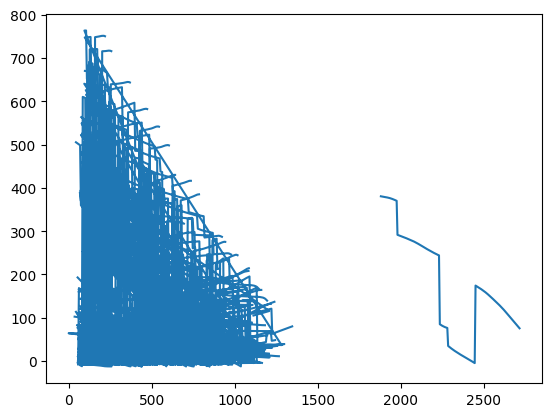

In [53]:
plt.plot(combined['Rel_x[m]_6'])

In [38]:
# save the dfs. 

dfs = new_dfs_2

for df in dfs: 

    df_sample = df.copy()

    veh_id = df_sample["vehicle_id"].unique()[0]

    path = f"data\\milano\\for_mtm_30\\leader_follower_pair_{veh_id}.csv"
    
    df_sample.to_csv(path)
    

### Import data. 

In [13]:
# Define the path to the directory containing the CSV files
path = 'data\\milano\\for_mtm\\'  

all_files = glob.glob(path + "leader_follower_pair_*.csv") #multiple neighbor
 
# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

In [14]:
len(dfs)

315

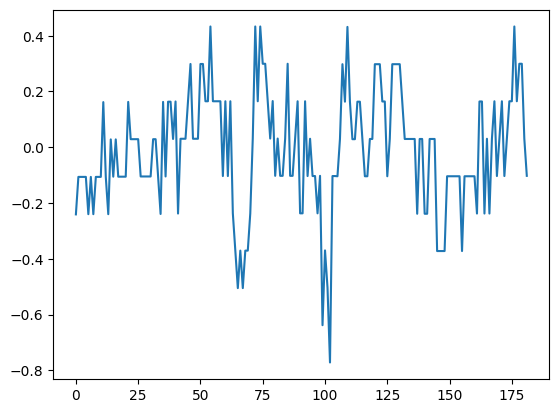

In [15]:
plt.plot(dfs[9]["Speed [km/h]_lat"])

In [7]:
#
list(dfs[0].columns)

['Unnamed: 0.1',
 'Unnamed: 0',
 'x[m]',
 'y[m]',
 'Speed [km/h]',
 'Tan. Acc. [ms-2]',
 'Lat. Acc. [ms-2]',
 'Time [s]',
 'Angle [rad]',
 'vehicle_id',
 'flw_type',
 'entry',
 'exit',
 'length',
 'width',
 'x_rot',
 'y_rot',
 'lanes',
 'x[m]_1',
 'y[m]_1',
 'Speed [km/h]_1',
 'Tan. Acc. [ms-2]_1',
 'Lat. Acc. [ms-2]_1',
 'Time [s]_1',
 'Angle [rad]_1',
 'vehicle_id_1',
 'flw_type_1',
 'entry_1',
 'exit_1',
 'length_1',
 'width_1',
 'x_rot_1',
 'y_rot_1',
 'lanes_1',
 'x[m]_2',
 'y[m]_2',
 'Speed [km/h]_2',
 'Tan. Acc. [ms-2]_2',
 'Lat. Acc. [ms-2]_2',
 'Time [s]_2',
 'Angle [rad]_2',
 'vehicle_id_2',
 'flw_type_2',
 'entry_2',
 'exit_2',
 'length_2',
 'width_2',
 'x_rot_2',
 'y_rot_2',
 'lanes_2',
 'x[m]_3',
 'y[m]_3',
 'Speed [km/h]_3',
 'Tan. Acc. [ms-2]_3',
 'Lat. Acc. [ms-2]_3',
 'Time [s]_3',
 'Angle [rad]_3',
 'vehicle_id_3',
 'flw_type_3',
 'entry_3',
 'exit_3',
 'length_3',
 'width_3',
 'x_rot_3',
 'y_rot_3',
 'lanes_3',
 'x[m]_4',
 'y[m]_4',
 'Speed [km/h]_4',
 'Tan. Acc. [ms

In [84]:
# removing the unreliable dfs 
# bitte nur einmal ausführen
dfs.pop(31)  # Remove the 72nd DataFrame (index 71)
dfs.pop(70)
dfs.pop(135)

,Unnamed: 0.1,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,...,Rel_x[m]_3,Rel_x[m]_4,Rel_x[m]_5,Rel_x[m]_6,Rel_y[m]_1,Rel_y[m]_2,Rel_y[m]_3,Rel_y[m]_4,Rel_y[m]_5,Rel_y[m]_6
0,94,531325,512228.67,5026318.27,77.6612,0.3723,-2.7656,125.025146,2.7365,500.0,...,NaN,18.167605,65.685812,NaN,0.969469,NaN,NaN,1.440627,0.077741,NaN
1,99,531330,512225.32,5026319.67,77.7893,0.0838,-1.4766,125.191980,2.7534,500.0,...,NaN,18.229946,65.587064,NaN,1.250751,NaN,NaN,1.677721,0.239669,NaN
2,104,531335,512221.95,5026321.03,77.7380,-0.2511,-0.1754,125.358814,2.7577,500.0,...,NaN,6.559686,18.292236,65.479317,2.133304,1.612578,NaN,1.762666,1.959536,0.606262
3,109,531340,512218.61,5026322.39,77.5114,-0.4846,0.7597,125.525647,2.7497,500.0,...,NaN,6.032259,18.381374,65.393955,1.868626,1.987917,NaN,1.511627,2.227966,0.950520
4,114,531345,512215.31,5026323.78,77.1806,-0.5975,1.3301,125.692481,2.7314,500.0,...,NaN,5.477958,18.488461,65.326543,1.630770,2.349921,NaN,1.296335,2.442750,1.241132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,1454,532685,511526.07,5026668.98,64.4931,0.0710,0.1032,170.403902,2.6532,500.0,...,NaN,NaN,22.099248,NaN,0.437191,2.062132,NaN,NaN,1.845044,NaN
273,1459,532690,511523.43,5026670.39,64.5103,-0.0083,0.0040,170.570736,2.6529,500.0,...,NaN,NaN,22.170869,NaN,0.503918,2.044208,NaN,NaN,1.903101,NaN
274,1464,532695,511520.78,5026671.79,64.4900,-0.0539,-0.0707,170.737570,2.6538,500.0,...,NaN,NaN,22.121736,NaN,0.552720,2.035234,NaN,NaN,1.956822,NaN
275,1469,532700,511518.14,5026673.19,64.4525,-0.0658,-0.1206,170.904403,2.6555,500.0,...,NaN,NaN,22.068142,NaN,0.614884,2.030746,NaN,NaN,2.019493,NaN


In [16]:
len(dfs)

315

recht seite ist für minus Zahlung und gegen. 

In [86]:
combined_df = pd.concat(dfs)

In [87]:
combined_df['y[m]'].describe()

count    6.136500e+04
mean     5.026497e+06
std      1.030320e+02
min      5.026310e+06
25%      5.026409e+06
50%      5.026501e+06
75%      5.026586e+06
max      5.026677e+06
Name: y[m], dtype: float64

In [88]:
combined_df['y_rot'].describe()

count    61365.000000
mean        92.493167
std          3.165181
min         87.509770
25%         90.410887
50%         91.730550
75%         95.253410
max        100.241938
Name: y_rot, dtype: float64

In [44]:
plt.figure(figsize=(10, 4))
plt.scatter(combined_df['x_rot'], combined_df['y_rot'])

NameError: name 'combined_df' is not defined

<Figure size 1000x400 with 0 Axes>

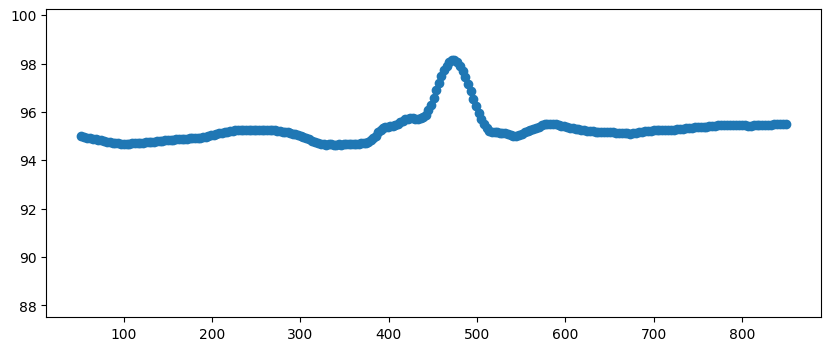

In [45]:
veh_no = 151
plt.figure(figsize=(10, 4))
plt.ylim(87.509770, 100.241938)
plt.scatter(dfs[veh_no]['x_rot'], dfs[veh_no]['y_rot'])

In [115]:
dfs[1][dfs[1]['lanes'] == 7]['x_rot'].values

array([], dtype=float64)

In [156]:
seventth_lane_values = []

for i in range(len(dfs)): 
     
    veh_no = i 

    values_list = dfs[veh_no][dfs[veh_no]['lanes'] == 7]['x_rot'].values

    seventth_lane_values.append(values_list)

In [157]:
len(seventth_lane_values)

312

In [50]:
list = [12,12,23,23]

In [168]:
# Count empty inner lists
num_empty = sum(1 for inner_list in seventth_lane_values if len(inner_list) == 0)

inbetween_seventh_lane = sum(1 for inner_list in seventth_lane_values if any(value > 500 for value in inner_list))
inbetween_seventh_lane_2 = sum(1 for inner_list in seventth_lane_values if any(value > 800 for value in inner_list))

count = 0 
for inner_list in seventth_lane_values:   
    if any(value > 450 for value in inner_list): 
        print(count)
    count = count + 1 

# Flatten the list and compute global minimum and maximum values
flattened_data = [value for inner_list in seventth_lane_values for value in inner_list]

flattened_data_2 = []

for value in flattened_data: 

    if value < 400: 

        flattened_data_2.append(value)
        

if flattened_data:  # Ensure the global list is not empty
    global_min = min(flattened_data_2)
    global_max = max(flattened_data_2)
else:
    global_min = None
    global_max = None

# Output results
print(f"Number of empty inner lists: {num_empty}")
if global_min is not None and global_max is not None:
    print(f"Global minimum value: {global_min}")
    print(f"Global maximum value: {global_max}")
else:
    print("Global list is empty.")

151
Number of empty inner lists: 224
Global minimum value: 50.0074478702154
Global maximum value: 397.907380065881


In [65]:
inbetween_seventh_lane

3

In [66]:
inbetween_seventh_lane_2

3

In [ ]:
combined_df['x_rot']

In [21]:
combined_df['lanes'].value_counts()

lanes
6.0    20778
5.0    19119
4.0    14298
7.0     4947
Name: count, dtype: int64

In [22]:
list(dfs[1].columns)

['Unnamed: 0',
 'x[m]',
 'y[m]',
 'Speed [km/h]',
 'Tan. Acc. [ms-2]',
 'Lat. Acc. [ms-2]',
 'Time [s]',
 'Angle [rad]',
 'vehicle_id',
 'flw_type',
 'entry',
 'exit',
 'length',
 'width',
 'x_rot',
 'y_rot',
 'lanes',
 'x[m]_1',
 'y[m]_1',
 'Speed [km/h]_1',
 'Tan. Acc. [ms-2]_1',
 'Lat. Acc. [ms-2]_1',
 'Time [s]_1',
 'Angle [rad]_1',
 'vehicle_id_1',
 'flw_type_1',
 'entry_1',
 'exit_1',
 'length_1',
 'width_1',
 'x_rot_1',
 'y_rot_1',
 'lanes_1',
 'x[m]_2',
 'y[m]_2',
 'Speed [km/h]_2',
 'Tan. Acc. [ms-2]_2',
 'Lat. Acc. [ms-2]_2',
 'Time [s]_2',
 'Angle [rad]_2',
 'vehicle_id_2',
 'flw_type_2',
 'entry_2',
 'exit_2',
 'length_2',
 'width_2',
 'x_rot_2',
 'y_rot_2',
 'lanes_2',
 'x[m]_3',
 'y[m]_3',
 'Speed [km/h]_3',
 'Tan. Acc. [ms-2]_3',
 'Lat. Acc. [ms-2]_3',
 'Time [s]_3',
 'Angle [rad]_3',
 'vehicle_id_3',
 'flw_type_3',
 'entry_3',
 'exit_3',
 'length_3',
 'width_3',
 'x_rot_3',
 'y_rot_3',
 'lanes_3',
 'x[m]_4',
 'y[m]_4',
 'Speed [km/h]_4',
 'Tan. Acc. [ms-2]_4',
 'Lat. Ac

In [17]:
dfs[56]['Rel_x[m]_5'].isna().sum()

0

In [18]:
indexs = 9 
print(f"{indexs+2}")

11


In [51]:
def lat_acc_int(mtm_instance, df, j): 
    
    '''
    The lateral acceleartion function to consider all the surrounding neighbors. (depends with the utilzed dataset) 
    '''

    lat_int_sum = 0 
    
    for i in range(1,7):
    
        if df.loc[j, f"x_rot_{i}"] != np.nan: 
    
            dx = df.loc[j, f'Rel_x[m]_{i}']  
            vx = df.loc[j, 'Speed [km/h]'] * 0.2777778
            y = df.loc[j, 'y_rot']
            yl  = df.loc[j, f'y_rot_{i}']
            vxl = df.loc[j, f'Speed [km/h]_{i}'] * 0.2777778
            vy = df.loc[j, 'Speed [km/h]_lat'] * 0.2777778           
            vyl = df.loc[j, f'Speed [km/h]_{i}_lat'] * 0.2777778 
            axl = df.loc[j, f'Tan. Acc. [ms-2]_{i}']
            Lveh = df.loc[j, 'length'] 
            Ll = df.loc[j, f'length_{i}']
            Wl = df.loc[j, f'width_{i}'] 
            Wveh = df.loc[j, 'width']
            Wroad = df.loc[j, "width_road"]
    
    
        lat_int = mtm_instance.calc_acc_lat_int(dx, y, yl, vx, vxl, vy, vyl, axl, Lveh, Ll, Wveh, Wl, Wroad)
    
        lat_int_sum = lat_int + lat_int_sum 
    
    return lat_int_sum


def long_acc_int(mtm_instance, df, j): 

    '''
    The long. acc. considering all the 3 leaders for the subject. 
    max. interaction is selected. 
    '''

    long_int_list = []

    for i in range(4,7): 
        
        dx = df.loc[j, f'Rel_x[m]_{i}']  
        dy = df.loc[j, f'Rel_y[m]_{i}']   # mtm takes abs, es ist uns egal. 
        vx = df.loc[j, 'Speed [km/h]'] * 0.2777778 
        vxl = df.loc[j, f'Speed [km/h]_{i}'] * 0.2777778
        axl = df.loc[j, f'Tan. Acc. [ms-2]_{i}']
        Ll = df.loc[j, f'length_{i}']
        Wavg = 0.5*(df.loc[j, 'width'] + df.loc[j, f'width_{i}'])
        
        long_int = mtm_instance.calc_acc_long_int(dx, dy, vx, vxl, axl, Ll, Wavg)

        long_int_list.append(long_int)

    
    max_long_acc_int = max(long_int_list)

    max_long_indx = long_int_list.index(max(long_int_list))

    return max_long_acc_int, max_long_indx
    

def sim(s0y, s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy, data):
    
    count = 0
    GAP_MIN = 0.4
    data = data.reset_index()
    dt = 0.2

    # mtm instance declaration. 
    MTM_model = MTM(IDM, s0y, s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy, acc_lat_b_max, acc_lat_b_ref, acc_long_b_ref, antic_factor_b)
    
    # convert pandas dataframe to arrays since left-assignment faster
    v1=np.empty(len(data), dtype=float)
    v2=np.empty(len(data), dtype=float)
    
    gap1=np.empty(len(data), dtype=float)
    gap2=np.empty(len(data), dtype=float)
    
    gapeuc =np.empty(len(data), dtype=float)
    gapeuc_orinal = np.empty(len(data), dtype=float)
    
    acc1=np.empty(len(data), dtype=float) # long. acc. 
    acc2=np.empty(len(data), dtype=float) # lat. acc. 

    # # restructure the gap data for the minimum gap. note. we use the euc. gap this time. 
    # gapData=data['gap_lead'].to_numpy() #take the long. gap lead. 
    # gapData2=data['gap_lead_lat'].to_numpy() 
    
    # for i in range(0,len(data)):
    #     gapData[i]=max(GAP_MIN,gapData[i])
    
    # inputs for bndry. acc. calculation 
    x =  data.loc[0, 'x_rot']
    y = data.loc[0, 'y_rot']
    vx = data.loc[0, 'Speed [km/h]'] * 0.2777778 
    vy = data.loc[0, 'Speed [km/h]_lat'] * 0.2777778
    Wveh = data.loc[0, 'width'] 
    
    # Wir benutzen normale beite zwischendurch auto mittelpunkt und boundary. Die MTM eq. für boundary einfluss 
    # bedenken über die actual gap. 
    width_left = data.loc[0, 'width_left']  
    width_right = data.loc[0, 'width_right']

    long_bndr_acc, lat_bndr_acc =  MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)
    long_int, leader_index = long_acc_int(MTM_model, data, 0)
    
    acc1[0] = long_int + long_bndr_acc 
    acc2[0] = lat_acc_int(MTM_model, data, 0) + MTM_model.calc_acc_lat_free(vy) +  lat_bndr_acc  
    # Wir vernachlässigen die frei beschwendigkeit, als wir haben kiene unbedingt Erfordernis. 

    # gap for the selected leader. 
    gap1[0] =  data.loc[0, f"Rel_x[m]_{leader_index+4}"] 
    gap2[0] =  data.loc[0, f"Rel_y[m]_{leader_index+4}"] 
    
    gapeuc[0] =  data.loc[0, f"gap_euc_{leader_index+4}"] 
    gapeuc_orinal[0] =  data.loc[0, f"gap_euc_{leader_index+4}"] 
    
    v1[0] = data.loc[0, 'Speed [km/h]'] * 0.2777778
    v2[0] = data.loc[0, 'Speed [km/h]_lat'] * 0.2777778
  
    # simulation
    for i in range(1,len(data)):

        v1[i] = v1[i-1] + acc1[i-1]*dt 
        v2[i] = v2[i-1] + acc2[i-1]*dt 
        
        v_lead = 0.5*(data.loc[i-1, f'Speed [km/h]_{leader_index+4}'] * 0.2777778 + data.loc[i, f'Speed [km/h]_{leader_index+4}'] * 0.2777778)
        v_lead_lat = 0.5*(data.loc[i-1, f'Speed [km/h]_{leader_index+4}_lat'] * 0.2777778 + data.loc[i, f'Speed [km/h]_{leader_index+4}_lat'] * 0.2777778)

        # long. gap. calc. 
        gap1[i] = gap1[i-1] + (v_lead - 0.5*(v1[i]+v1[i-1]))*dt

        # all the given conditions are the same. take it to a one line 
        # right is plus and left is negative. based on that concept. 
        ############################################################################################################
        # lat. gap. calc. 
        if (v2[i] > 0 and v_lead_lat > 0) or (v2[i] < 0 and v_lead_lat < 0): 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
                        
        if v2[i] > 0 and v_lead_lat < 0: # assume that this is the one that vehicles goes apart. if not change 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt

        if v2[i] < 0 and v_lead_lat > 0: # assume that this is the one that vehicles comes close to each other. 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
        ##################################################################################################################

        # euc. gap. 
        gapeuc[i] =  math.sqrt((gap1[i])**2 + (gap2[i])**2)
        gapeuc_orinal[i] =  data.loc[i, f"gap_euc_{leader_index+4}"] 

        
        # adjustments 
        #######################################################################################################################################################
        # if estimated speed negative, assume a stop and no further decel        
        if v1[i]<-1e-6:  # then acc1 strictly<0
            v1[i]=0
            gap1[i]= gap1[i-1 ] + v_lead*dt -(-0.5*v1[i-1]**2/acc1[i-1])


        # since the leader now change all the time, we will not use this. 
        
                # # reset gap if new leader
        # if data.loc[i,'vehicle_id_l']!=data.loc[i-1,'vehicle_id_l']:
        #         gap1[i] = gapData[i] 
        #         gap2[i] = gapData2[i] 

        ################################################################################################################################################################


        # inputs for ith long. int. acc. calculation 
        x =  data.loc[i, 'x_rot']
        y = data.loc[i, 'y_rot']
        vx = data.loc[i, 'Speed [km/h]'] * 0.2777778 
        vy = data.loc[i, 'Speed [km/h]_lat'] * 0.2777778
        Wveh = data.loc[i, 'width'] 
        
        width_left = data.loc[i, 'width_left']
        width_right = data.loc[i, 'width_right']

        # long. and lat. acc. calculation. for ith instance. 
        long_bndr_acc, lat_bndr_acc =  MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)
        long_int, leader_index = long_acc_int(MTM_model, data, i)

        
        acc1[i] = long_int + long_bndr_acc
        acc2[i] = lat_acc_int(MTM_model, data, i)  +  MTM_model.calc_acc_lat_free(vy)   +  lat_bndr_acc   

    
    # re-convert arrays to dataframe to be consistent
    # (this one-shot conversion is fast)
    
    data['v1'] = v1.tolist()
    data['v2'] = v2.tolist()
    data['gap1'] = gap1.tolist()
    data['gap2'] = gap2.tolist()
    data['acc1'] = acc1.tolist()
    data['acc2'] = acc2.tolist()
    data['gapeuc_sim'] = gapeuc.tolist()
    data['gapeuc_original'] = gapeuc_orinal.tolist()

    sse= sum((data['gapeuc_original'] - data['gapeuc_sim'])**2)
    
    avg_error = np.sqrt(sse/len(data))

    return  sse,avg_error,data


def data_sim(data,follower):
    
    d1=data[follower]
    d1=d1.dropna(subset=['vehicle_id'])

    return d1

def normparams(x0):
    
    x1=[0,0,0,0,0,0,0]
    
    x1[0] = (x0[0]-0.05)/1
    x1[1] = (x0[1]-0.05)/1
    x1[2] = (x0[2]-0.05)/1
    x1[3] = (x0[3]-0.05)/1
    x1[4] = (x0[4]-0.05)/1
    x1[5] = (x0[5]-0.05)/5
    x1[6] = (x0[6]-0.05)/1
    
    return x1

def denormparams(x1):
    
    x0=[0,0,0,0,0,0,0]
    
    x0[0]=np.minimum(np.maximum((x1[0]*1+0.05),0.05),1)  
    x0[1]=np.minimum(np.maximum((x1[1]*1+0.05),0.05),1) 
    x0[2]=np.minimum(np.maximum((x1[2]*1+0.05),0.05),1) 
    x0[3]=np.minimum(np.maximum((x1[3]*1+0.05),0.05),1) 
    x0[4]=np.minimum(np.maximum((x1[4]*1+0.05),0.05),1) 
    x0[5]=np.minimum(np.maximum((x1[5]*5+0.05),0.05),5) 
    x0[6]=np.minimum(np.maximum((x1[6]*1+0.05),0.05),1) 

    return x0
# geneticalgoritm package. 

def calib(x,data,follower):
    
    x0 = denormparams(x)
    s0y = np.minimum(np.maximum(x0[0],0.05),1)
    s0y_lat = np.minimum(np.maximum(x0[1],0.05),1)
    s0y_b = np.minimum(np.maximum(x0[2],0.05),1)
    s0y_lat_b = np.minimum(np.maximum(x0[3],0.05),1)
    sens_lat = np.minimum(np.maximum(x0[4],0.05),1)
    tau_lat_ovm = np.minimum(np.maximum(x0[5],0.05),5)
    sens_dvy = np.minimum(np.maximum(x0[6],0.05),1)   
    
    return sim(s0y , s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy,  data_sim(data,follower))[0]


def optim(x,data_ideal,follower):

    #optim function to be used in parallerisation using Nelder-Mead method
    res = minimize(calib, x, (data_ideal,follower), method='Nelder-Mead')
    
    return res.x


def optim_results(data_ideal,result,followers):
    
    d={'Follower':[],'s0y':[],'s0y_lat':[],'s0y_b':[],'s0y_lat_b':[],'sens_lat':[], 'tau_lat_ovm':[], 'sens_dvy':[],'SSE':[],'GOF':[]}
    
    for _ in range(len(result)):

        results_denorm = denormparams((result[_])) 
        
        d['Follower'].append(followers[_])
        
        d['s0y'].append(results_denorm[0])
        d['s0y_lat'].append(results_denorm[1])
        d['s0y_b'].append(results_denorm[2])
        d['s0y_lat_b'].append(results_denorm[3])
        d['sens_lat'].append(results_denorm[4])
        d['tau_lat_ovm'].append(results_denorm[5])
        d['sens_dvy'].append(results_denorm[6])
        
        d['SSE'].append(sim(*(results_denorm),data_sim(data_ideal,followers[_]))[0])
        d['GOF'].append(sim(*(results_denorm),data_sim(data_ideal,followers[_]))[1])
    
    return d


Wir mussen die negative und positive sign für die euc entfernung ergänzen. Weil die abs Zahlung hat keine Ahnung über die lecht oder Reicht. 

#################################################################################################
## lat. gap. calc. . it was identified that the following logic is wrong
if (v2[i] > 0 and v_lead_lat > 0) or (v2[i] < 0 and v_lead_lat < 0): 
 gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
            
if v2[i] > 0 and v_lead_lat < 0: # assume that this is the one that vehicles goes apart. if not change 
 gap2[i] = gap2[i-1] + (v_lead_lat  + 0.5*(v2[i]+v2[i-1]))*dt

if v2[i] < 0 and v_lead_lat > 0: # assume that this is the one that vehicles comes close to each other. 
 gap2[i] = abs(-gap2[i-1] + (v_lead_lat  + 0.5*(v2[i]+v2[i-1]))*dt) 
###############################################################################################

### Testing 

In [20]:
os.getcwd()

'C:\\Users\\HP\\Desktop\\Research'

In [37]:
os.chdir("C:\\Users\\HP\\Desktop\\Research\\mixed_traffic_models")

In [38]:
from mixed_traffic_model import MTM

In [39]:
from longitudinal_cfmodels import IDM, ACC 

In [40]:
# IDM implimentierung 
IDM =  IDM(28.21184, 0.496054, 1.179394, 1.990027, 1.824150)

In [41]:
acc_lat_b_max = 2 # antic time for boundary response (multiples of T)
acc_lat_b_ref = 20 # /max boundary lat accel, of the order of bmax
acc_long_b_ref =  2 # longitudinal acceleration if veh touches boundary
antic_factor_b = 4

In [42]:
len(dfs)

315

In [43]:
data = dfs[30]

In [44]:
len(data)

147

In [52]:
results = sim(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 , data)

In [53]:
results[2]["gap2"]

0         1.739097
1         1.844140
2         2.162899
3         2.690163
4         3.428465
          ...     
142    1730.434598
143    1753.822113
144    1777.519393
145    1801.623773
146    1826.190857
Name: gap2, Length: 147, dtype: float64

In [54]:
results[2]['acc1'].min()

-0.8357620231056835

In [55]:
results[2]

,index,Unnamed: 0.1,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],...,Rel_y[m]_5,Rel_y[m]_6,v1,v2,gap1,gap2,acc1,acc2,gapeuc_sim,gapeuc_original
0,0,56,153864,512223.83,5026310.64,118.2183,0.3216,-0.0051,28.328356,2.6820,...,1.161508,NaN,32.838419,0.010356,25.173817,1.739097,-0.174187,-5.439990,25.233817,25.233817
1,1,61,153869,512218.91,5026313.07,118.4280,0.3652,-0.0027,28.495189,2.6820,...,1.169798,NaN,32.803582,-1.077642,25.076840,1.844140,-0.181272,-5.431546,25.144557,25.144581
2,2,66,153874,512213.99,5026315.51,118.6580,0.3928,-0.0025,28.662023,2.6820,...,1.173650,NaN,32.767328,-2.163951,24.994335,2.162899,-0.186961,-5.366229,25.087745,25.050275
3,3,71,153879,512209.05,5026317.95,118.8945,0.3844,-0.0037,28.828857,2.6821,...,1.181990,NaN,32.729935,-3.237197,24.928493,2.690163,-0.194215,-5.185645,25.073227,24.938731
4,4,76,153884,512204.11,5026320.39,119.1229,0.3879,-0.0092,28.995690,2.6821,...,1.185869,NaN,32.691092,-4.274326,24.881418,3.428465,-0.200763,-5.778284,25.116515,24.840881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,142,766,154574,511528.64,5026656.60,118.9468,0.5176,-0.1195,52.018736,2.6811,...,1.306382,NaN,24.456602,-116.324618,129.917336,1730.434598,-0.503917,-6.772091,1735.304703,24.193993
143,143,771,154579,511523.71,5026659.05,119.3681,0.8900,-0.1592,52.185569,2.6818,...,1.292107,NaN,24.355818,-117.679036,131.288836,1753.822113,-0.581074,-8.719351,1758.729303,24.070729
144,144,776,154584,511518.75,5026661.50,120.0745,1.4690,-0.2005,52.352403,2.6829,...,1.286782,NaN,24.239604,-119.422907,132.503278,1777.519393,-0.730580,-11.455199,1782.451208,23.756882
145,145,781,154589,511513.77,5026663.96,121.0002,1.6129,-0.2261,52.519237,2.6841,...,1.254583,NaN,24.093488,-121.713946,133.442233,1801.623773,-0.793127,-11.873107,1806.558897,23.130746


In [56]:
import matplotlib.pyplot as plt 

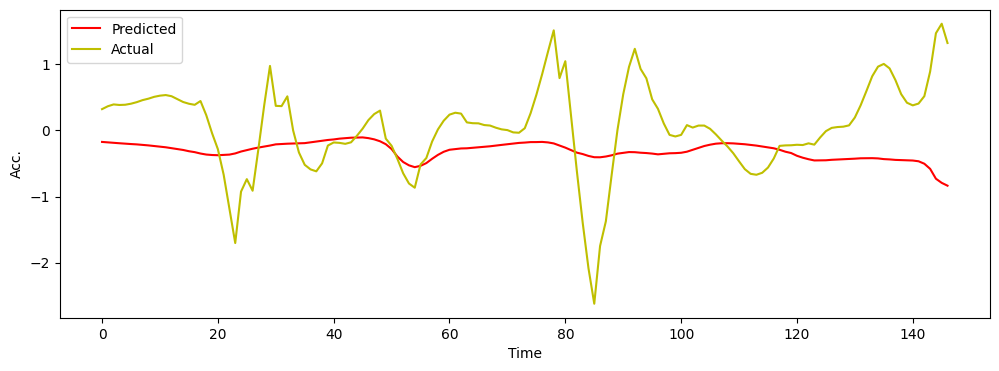

In [57]:
## acc visualize 
plt.figure(figsize=(12, 4))

plt.plot(results[2]['acc1'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['Tan. Acc. [ms-2]'],   color='y',  label = 'Actual')

plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

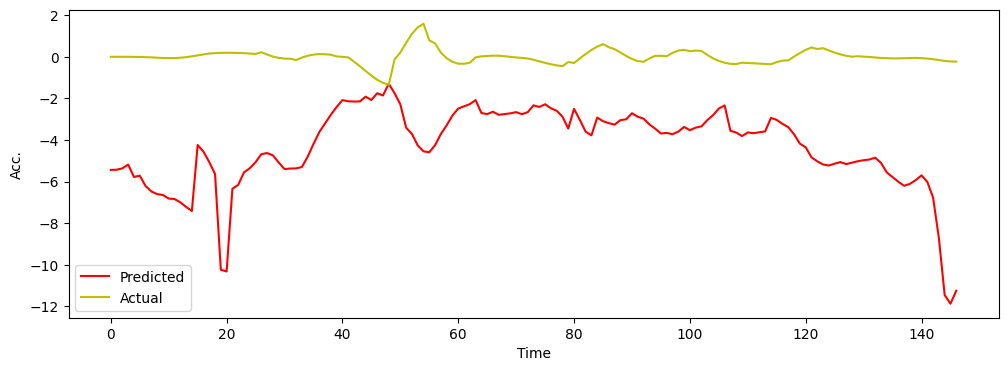

In [58]:
## acc visualize 
plt.figure(figsize=(12, 4))

plt.plot(results[2]['acc2'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['Lat. Acc. [ms-2]'],   color='y',  label = 'Actual')

plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

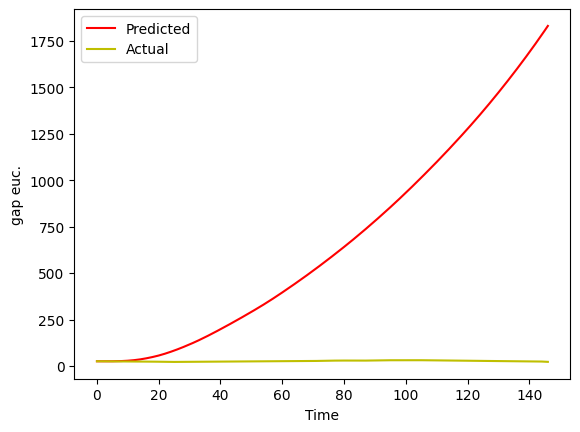

In [59]:
plt.plot(results[2]['gapeuc_sim'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['gapeuc_original'],   color='y',  label = 'Actual')

plt.ylabel("gap euc.")
plt.xlabel('Time')
plt.legend()

#plt.xlim(0, 40)

plt.show()

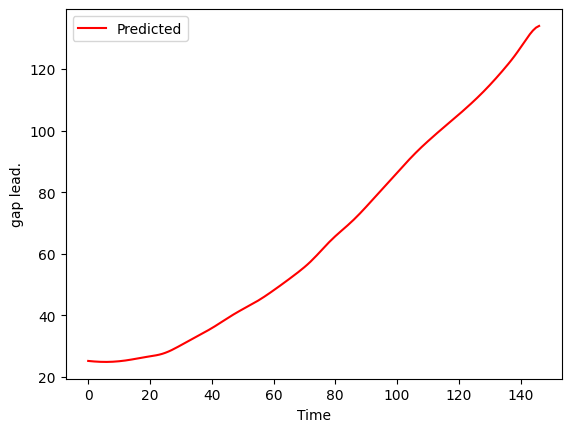

In [60]:
plt.plot(results[2]['gap1'] ,   color='r',  label = 'Predicted')
# plt.plot(results[2]['gap_lead'],   color='y',  label = 'Actual')

plt.ylabel("gap lead.")
plt.xlabel('Time')
plt.legend()

plt.show()

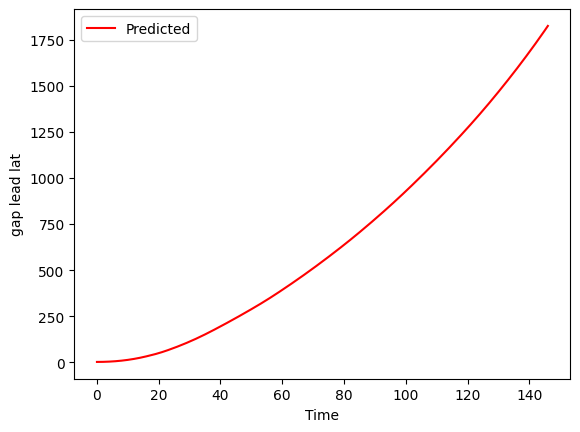

In [61]:
plt.plot(results[2]['gap2'] ,   color='r',  label = 'Predicted')
# plt.plot(results[2]['gap_lead_lat'],   color='y',  label = 'Actual')

plt.ylabel("gap lead lat")
plt.xlabel('Time')
plt.legend()

plt.show()

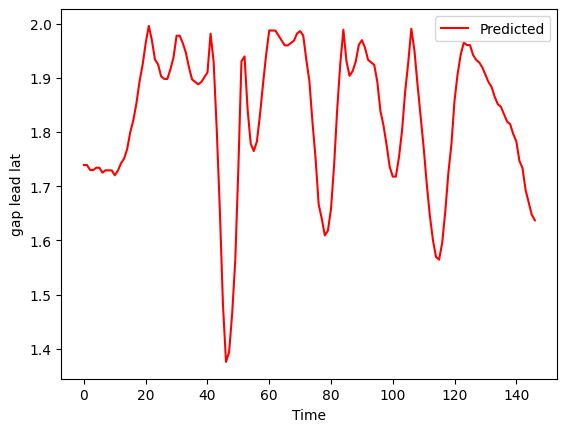

In [214]:
plt.plot(data['Rel_y[m]_4'] ,   color='r',  label = 'Predicted')
# plt.plot(results[2]['gap_lead_lat'],   color='y',  label = 'Actual')

plt.ylabel("gap lead lat")
plt.xlabel('Time')
plt.legend()

plt.show()

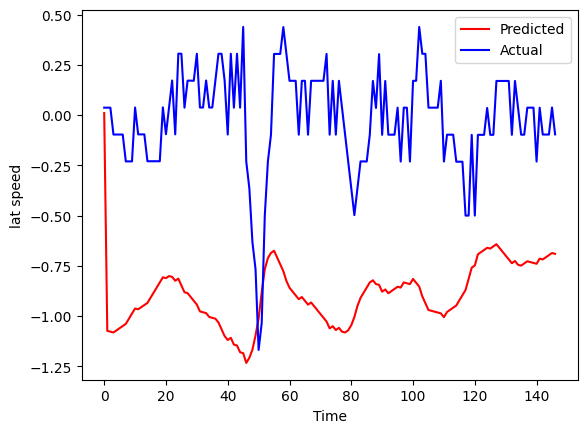

In [300]:
plt.plot(results[2]['v2'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]["Speed [km/h]_lat"] ,   color='b',  label = 'Actual')

plt.ylabel("lat speed")
plt.xlabel('Time')
plt.legend()

plt.show()

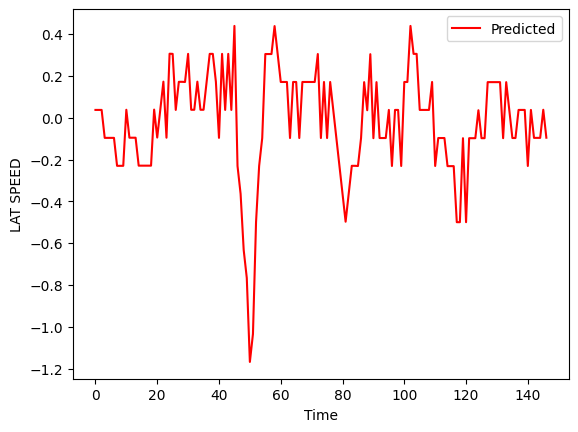

In [246]:
plt.plot(results[2]["Speed [km/h]_lat"] ,   color='r',  label = 'Predicted')
# plt.plot(results[2]['gap_lead_lat'],   color='y',  label = 'Actual')

plt.ylabel("LAT SPEED")
plt.xlabel('Time')
plt.legend()

plt.show()


In [ ]:
changes need to be make:
- the width of the road section based on the distannce, 4 lane or 3 lanes. - Wir können es in einem sehr einfach Weise machen, weil wir es direkt um df eingeben.  
- reverse the length of the data. 
- denken über die vier Global constraints. 
    - acc_lat_b_max, acc_lat_b_ref, acc_long_b_ref, antic_factor_b: Global constants.
    - not used, for the boudary, for the bouday, not used. (not used are due to the not using the anticipation in the boundary. ) 

### MTM calibration 

In [17]:
import time 
from scipy.optimize import minimize, rosen
from joblib import Parallel, delayed
import multiprocessing

In [18]:
data_list = dfs[:2]

In [20]:
x = normparams((0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1))

num_cores=4
st=time.time()

print(f'Optimisation started for {len(data_list )} vehicels using {num_cores} cores ')

result = Parallel(n_jobs=num_cores)(delayed(optim)(x=x, data_ideal=data_list ,follower=f) for f in range(len(data_list )))

results=optim_results(data_list ,result,range(len(data_list )))

# with open(rf'C:\Users\HP\Desktop\Research\IDM_calib\optim_results_single_leader.pkl','wb') as fp:
#     pickle.dump(results,fp)

Optimisation started for 2 vehicels using 4 cores 


C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_right = min(v0y_b_left, sy_right/TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_right = min(v0y_b_left, sy_right/TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280:

In [21]:
results

{'Follower': [0, 1],
 's0y': [0.10125246747917704, 0.09985235163600024],
 's0y_lat': [0.09999447119954237, 0.1025281802510252],
 's0y_b': [0.10124617863701423, 0.10065853149166928],
 's0y_lat_b': [0.09999997947622317, 0.09953713489664294],
 'sens_lat': [0.1000016789350094, 0.09963647528269645],
 'tau_lat_ovm': [0.10000540001379803, 0.09964229076925588],
 'sens_dvy': [0.10000322895019956, 0.10033061170140838],
 'SSE': [24942112.850038756, 116871.1486831306],
 'GOF': [427.2707076292087, 28.688608511601004]}

In [ ]:
meine nächste stiffen 

1. Solvieren long. seitliche acc.
2. Sprechen mit Ankit über probleme. 
    2.1. die euc. distance ist nicht sehr gute parameter. die Einfluss von setiliche Lücke ist sehr Gering. wir können nur die Einfluss von long. Lucke sehen. 
    2.2. lang. veränderung auch können wir catch nicht. weil alle Dinge kommt über euc. Entfernung an. 
3. Versuche über verschiendene optimizierung techniques 